<a href="https://colab.research.google.com/github/stevefreund88-collab/hello-lab/blob/main/exercise_5_1_polynomial_features_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5.1: Polynomial Features
## Transform linear data to capture curves

**Learning Objectives:**
- Understand how polynomial features can capture non-linear relationships
- Learn to create polynomial features manually and with sklearn
- Visualize the impact of polynomial transformations
- Compare linear vs polynomial model performance

**Skills:** Feature transformation impact, non-linear modeling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

## Part 1: Generate Non-Linear Data

We'll create synthetic data with a quadratic relationship plus some noise.

In [3]:
# Generate non-linear data
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = 0.5 * X**2 + X + 2  # Quadratic relationship
y = y_true + np.random.randn(100, 1) * 0.5  # Add noise

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nOriginal feature shape: {X_train.shape}")

Training samples: 80
Test samples: 20

Original feature shape: (80, 1)


## Part 2: Visualize the Original Data

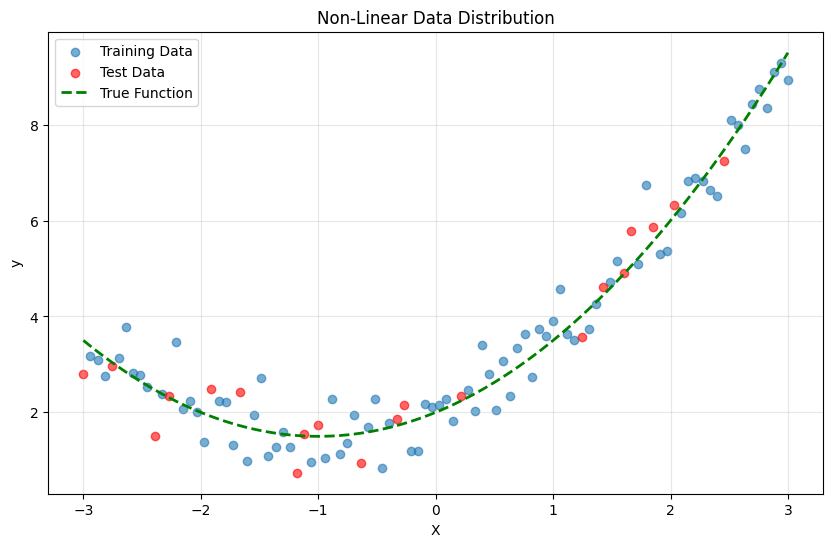

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.6, label='Training Data')
plt.scatter(X_test, y_test, alpha=0.6, color='red', label='Test Data')
plt.plot(X, y_true, 'g--', linewidth=2, label='True Function')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Non-Linear Data Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 3: Linear Model (Baseline)

First, let's try fitting a simple linear model to see how it performs on non-linear data.

In [6]:
# Train linear model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Calculate metrics
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Model Performance:")
print(f"MSE: {mse_linear:.4f}")
print(f"R² Score: {r2_linear:.4f}")
print(f"\nModel equation: y = {linear_model.coef_[0][0]:.2f}x + {linear_model.intercept_[0]:.2f}")

Linear Model Performance:
MSE: 1.5104
R² Score: 0.5655

Model equation: y = 1.04x + 3.55


## Part 4: Manual Polynomial Feature Creation

Let's manually create polynomial features to understand the transformation.

In [8]:
# TODO: Manually create polynomial features (degree 2)
# For each sample x, create features: [1, x, x²]

def create_polynomial_features_manual(X, degree=2):
    """
    Manually create polynomial features.

    Args:
        X: Input features (n_samples, 1)
        degree: Polynomial degree

    Returns:
        Polynomial features (n_samples, degree+1)
    """
    # Your code here
    features = []
    for d in range(degree + 1):
        features.append(X ** d)

    return np.hstack(features)

# Test your function
X_poly_manual = create_polynomial_features_manual(X_train, degree=2)
print(f"Original shape: {X_train.shape}")
print(f"Polynomial features shape: {X_poly_manual.shape}")
print(f"\nFirst sample transformation:")
print(f"Original: {X_train[0]}")
print(f"Polynomial: {X_poly_manual[0]}")

Original shape: (80, 1)
Polynomial features shape: (80, 3)

First sample transformation:
Original: [0.33333333]
Polynomial: [1.         0.33333333 0.11111111]


## Part 5: Sklearn Polynomial Features

Now let's use sklearn's PolynomialFeatures class.

In [9]:
# TODO: Create polynomial features using sklearn
# Try different degrees: 2, 3, 4

degrees = [2, 3, 4]
results = {'Linear': {'mse': mse_linear, 'r2': r2_linear}}

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    print(f"\nDegree {degree}:")
    print(f"Number of features: {X_train_poly.shape[1]}")
    print(f"Feature names: {poly.get_feature_names_out()}")

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Evaluate
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[f'Degree {degree}'] = {'mse': mse, 'r2': r2, 'model': model, 'poly': poly}

    print(f"MSE: {mse:.4f}")
    print(f"R² Score: {r2:.4f}")


Degree 2:
Number of features: 3
Feature names: ['1' 'x0' 'x0^2']
MSE: 0.2250
R² Score: 0.9353

Degree 3:
Number of features: 4
Feature names: ['1' 'x0' 'x0^2' 'x0^3']
MSE: 0.2374
R² Score: 0.9317

Degree 4:
Number of features: 5
Feature names: ['1' 'x0' 'x0^2' 'x0^3' 'x0^4']
MSE: 0.2197
R² Score: 0.9368


## Part 6: Visualize All Models

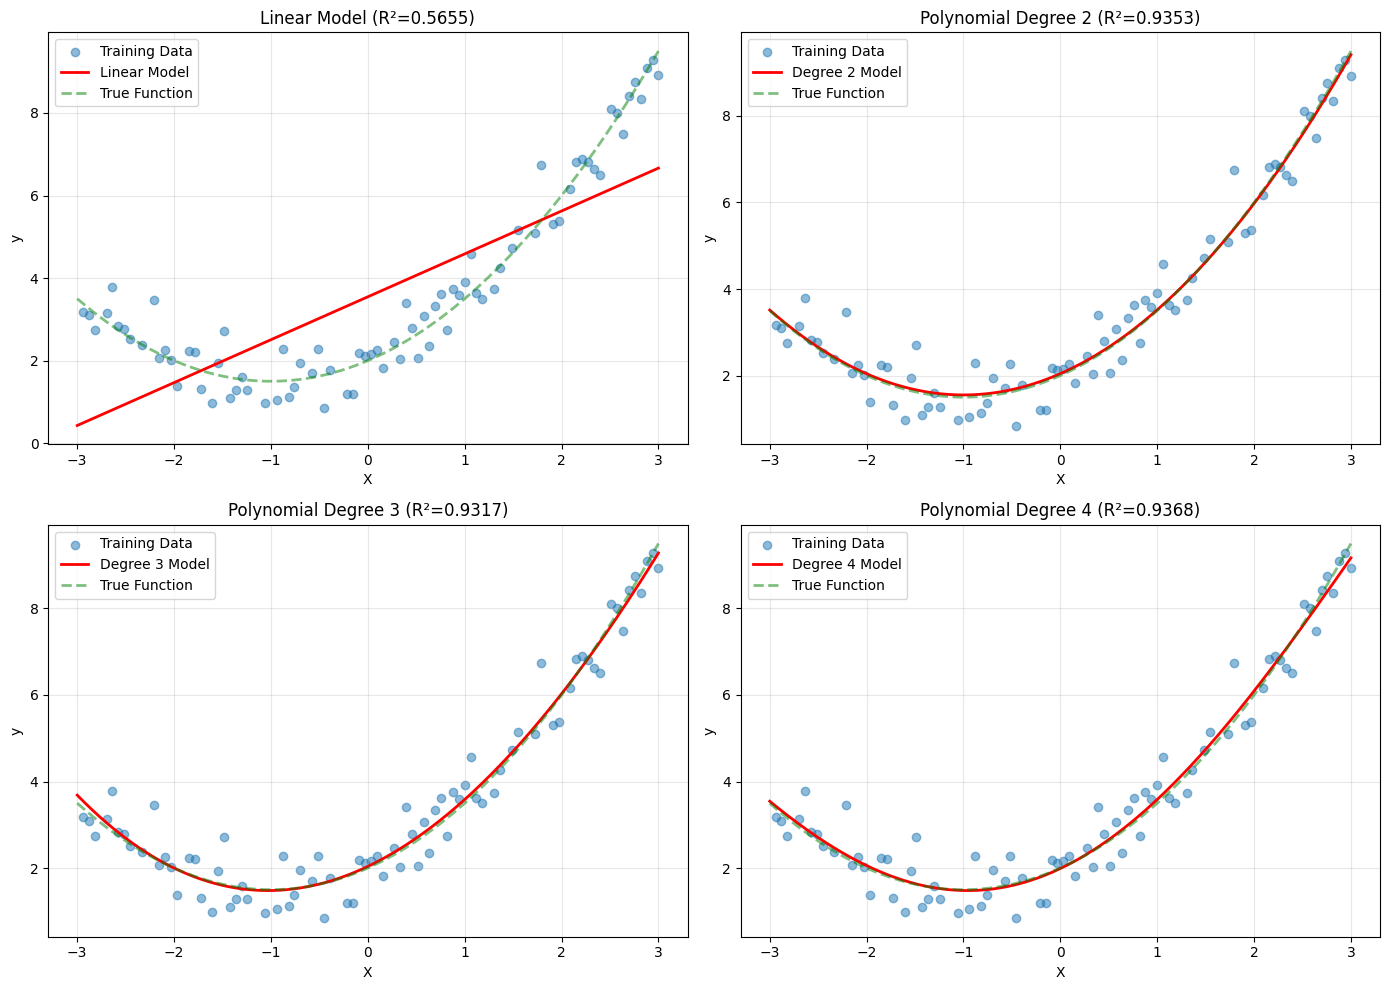

In [10]:
# Create dense points for smooth curves
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.figure(figsize=(14, 10))

# Plot 1: Linear model
plt.subplot(2, 2, 1)
plt.scatter(X_train, y_train, alpha=0.5, label='Training Data')
plt.plot(X_plot, linear_model.predict(X_plot), 'r-', linewidth=2, label='Linear Model')
plt.plot(X, y_true, 'g--', linewidth=2, alpha=0.5, label='True Function')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Linear Model (R²={r2_linear:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot polynomial models
for idx, degree in enumerate(degrees, start=2):
    plt.subplot(2, 2, idx)

    model_info = results[f'Degree {degree}']
    model = model_info['model']
    poly = model_info['poly']

    X_plot_poly = poly.transform(X_plot)
    y_plot = model.predict(X_plot_poly)

    plt.scatter(X_train, y_train, alpha=0.5, label='Training Data')
    plt.plot(X_plot, y_plot, 'r-', linewidth=2, label=f'Degree {degree} Model')
    plt.plot(X, y_true, 'g--', linewidth=2, alpha=0.5, label='True Function')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Polynomial Degree {degree} (R²={model_info["r2"]:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 7: Compare Model Performance

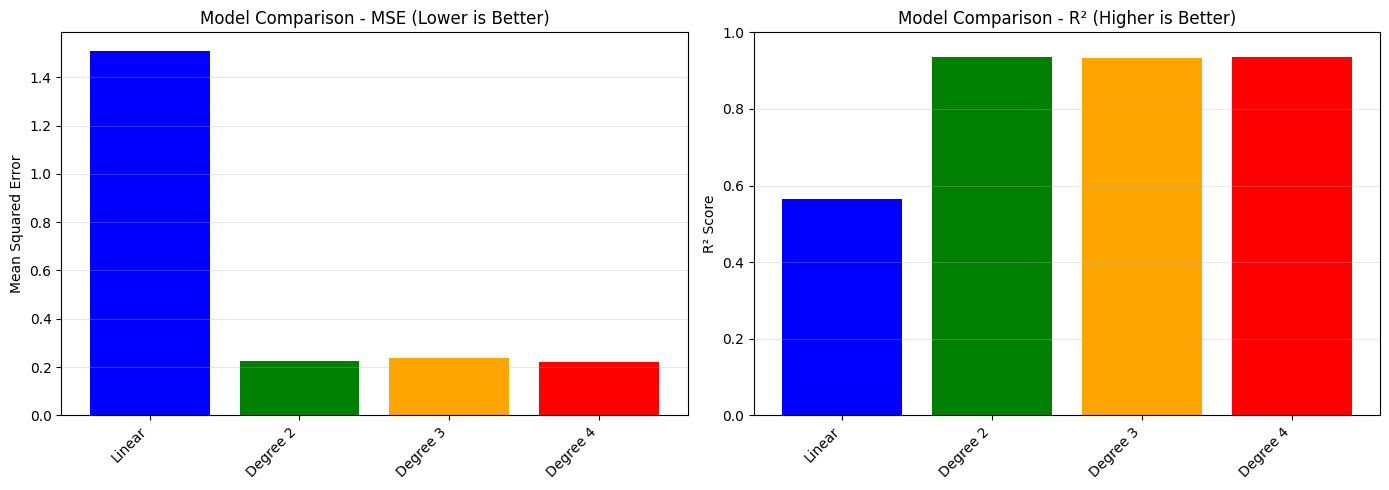


MODEL PERFORMANCE SUMMARY

Linear:
  MSE: 1.5104
  R²:  0.5655

Degree 2:
  MSE: 0.2250
  R²:  0.9353

Degree 3:
  MSE: 0.2374
  R²:  0.9317

Degree 4:
  MSE: 0.2197
  R²:  0.9368


In [11]:
# Create comparison bar chart
model_names = list(results.keys())
mse_values = [results[name]['mse'] for name in model_names]
r2_values = [results[name]['r2'] for name in model_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MSE comparison
ax1.bar(model_names, mse_values, color=['blue', 'green', 'orange', 'red'])
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('Model Comparison - MSE (Lower is Better)')
ax1.grid(True, alpha=0.3, axis='y')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# R² comparison
ax2.bar(model_names, r2_values, color=['blue', 'green', 'orange', 'red'])
ax2.set_ylabel('R² Score')
ax2.set_title('Model Comparison - R² (Higher is Better)')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)
for name in model_names:
    print(f"\n{name}:")
    print(f"  MSE: {results[name]['mse']:.4f}")
    print(f"  R²:  {results[name]['r2']:.4f}")

## Part 8: Challenge - Overfitting Detection

Experiment with very high polynomial degrees to see overfitting.


Degree 5:
  Train R²: 0.9606
  Test R²:  0.9391
  Gap:      0.0215

Degree 10:
  Train R²: 0.9613
  Test R²:  0.9359
  Gap:      0.0253

Degree 15:
  Train R²: 0.9620
  Test R²:  0.9175
  Gap:      0.0445


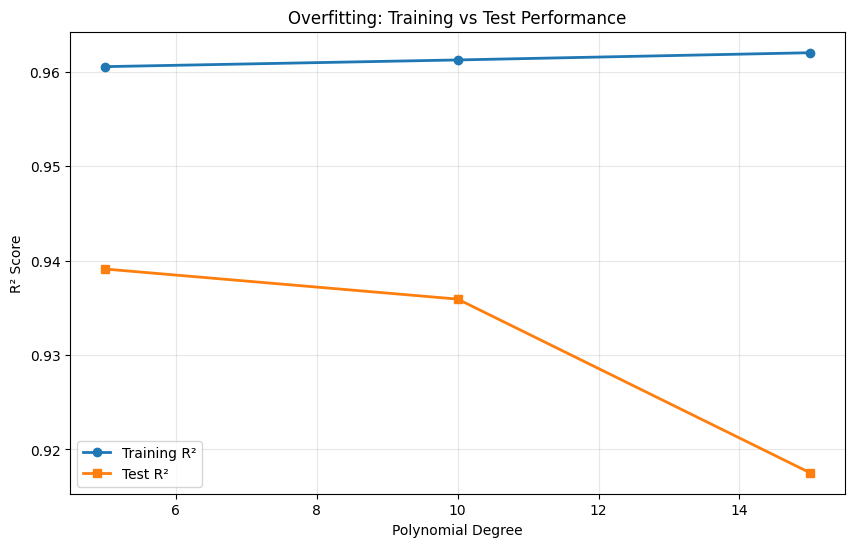

In [12]:
# TODO: Try polynomial degrees 5, 10, 15
# Compare training vs test performance to detect overfitting

high_degrees = [5, 10, 15]

train_scores = []
test_scores = []

for degree in high_degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_score = r2_score(y_train, model.predict(X_train_poly))
    test_score = r2_score(y_test, model.predict(X_test_poly))

    train_scores.append(train_score)
    test_scores.append(test_score)

    print(f"\nDegree {degree}:")
    print(f"  Train R²: {train_score:.4f}")
    print(f"  Test R²:  {test_score:.4f}")
    print(f"  Gap:      {train_score - test_score:.4f}")

# Visualize overfitting
plt.figure(figsize=(10, 6))
plt.plot(high_degrees, train_scores, 'o-', label='Training R²', linewidth=2)
plt.plot(high_degrees, test_scores, 's-', label='Test R²', linewidth=2)
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Overfitting: Training vs Test Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Key Takeaways

1. **Polynomial features** allow linear models to capture non-linear relationships
2. **Feature transformation**: Converting x to [1, x, x²] creates polynomial features
3. **Model complexity**: Higher degree polynomials can fit training data better
4. **Overfitting risk**: Very high degrees may memorize training data
5. **Trade-off**: Balance between model complexity and generalization

## Questions to Consider

- Which polynomial degree performed best on the test set? Degree 4 performed a little better than the others. Degree 2 was a close second.
- Why does degree 2 work well for our data? Degree 2 works well for it is represented by a U-shapred parabolic curve.
- What signs of overfitting did you observe with high degrees? The R2 numbers can show overfitting. And while there are some hits to overfitting between the training and testing data, it is not clear that overfitting has occured.
- When would you use polynomial features in real projects? Polynomials will likley be sued with non-linear representations (such as the U p[resent in Degree 2). I could hit to two underlying factors.